# Predicting Sentiment Toward Apple and Google Products Using Tweets

# 1. Project Summary

This project explores the use of machine learning to classify the sentiment of tweets discussing Apple and Google products. The dataset contains over 9,000 tweets that were manually labeled as positive, neutral, or negative. Sentiment analysis can help organizations better understand customer opinions, identify product issues, and monitor public perception on social media. Because the data consists of short user-generated text, it provides a practical setting for applying natural language processing (NLP) techniques.

Several data preparation steps were performed before modeling. Missing values and duplicate records were removed, and the tweet text was cleaned by converting text to lowercase, removing punctuation, URLs, and other unnecessary characters. The cleaned text was then transformed into numerical features using the TF-IDF vectorization technique. Pandas and NumPy were used for data manipulation, while NLTK was used for text preprocessing and scikit-learn was used for feature extraction and model development.

Multiple classification models were trained and evaluated, including a Dummy Classifier, Logistic Regression, Decision Tree, Tuned Decision Tree, and Random Forest. Model performance was assessed using accuracy, precision, recall, macro F1-score, and confusion matrices. Macro F1-score was selected as the primary evaluation metric because the dataset contains an imbalanced distribution of sentiment classes.

Among the models tested, Logistic Regression produced the strongest overall results with an accuracy of 63.1% and a macro F1-score of 0.56. It also achieved the highest recall for negative tweets, making it the most effective model for identifying customer dissatisfaction. The results demonstrate that machine learning can be used to classify social media sentiment and provide useful insights into customer opinions regarding technology products.


# 2. Business Understanding
## 2.1 Business Problem
Apple and Google receive large amounts of public feedback through social media. Tweets can show whether customers are excited, disappointed, confused, or neutral about a product. However, manually reviewing thousands of tweets is slow and inefficient. The business problem is that marketing and customer experience teams need a faster way to understand public sentiment toward Apple and Google products.

## 2.2 Stakeholder
The main stakeholders are Apple and Google product marketing teams, Apple and Google customer experience teams and social media monitoring teams. These stakeholders could use the model to quickly identify public reactions to products, launches, events, and customer complaints.

## 2.3 Project Objective
The goal of this project is to build a Natural Language Processing classification model that predicts the sentiment of a tweet based on its text. The final model should classify tweets as positive, negative or neutral.

## 2.4 Business Value
The model could help stakeholders monitor public opinion faster, detect negative tweets earlier, understand which products receive more positive or negative feedback, support customer experience decisions and track sentiment during product launches or public events.

## 2.5 Success Metric
The main metric will be macro F1-score.
Macro F1-score is useful because this dataset has imbalanced classes. The number of neutral, positive and negative tweets is different. Accuracy alone may make the model look strong even if it performs poorly on the smaller class.

The project will also report accuracy, precision, recall, weighted F1-score and confusion matrix. Because the stakeholder cares about identifying negative feedback, recall for the negative class will also be important.

# 3. Data Understanding

This section explores the tweet sentiment dataset before modeling. The goal is to understand the structure of the data, check for missing values, review the sentiment labels, and identify any data quality issues that need to be fixed before building NLP models.

## 3.1 Import Relevant Libraries

In [3]:
#importing relevant libraries

# Import data analysis libraries
import pandas as pd
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import text processing libraries
import re
import string
import nltk

# Import machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Import models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 3.2 Load the Dataset

In [4]:
# Load the dataset
df = pd.read_csv("judge-1377884607_tweet_product_company.csv", encoding="latin1")

# Display the first five rows
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [5]:
# Check the shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (9093, 3)


## 3.3 Preview the Dataset Structure

In [6]:
# Display column names 
df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='object')

In [7]:
# Check data types and non-null counts 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [8]:
# Display a random sample of five rows 
df.sample(5, random_state=42)

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
5558,RT @mention best thing abt @mention for #SXSW?...,NaN,No emotion toward brand or product
8350,Gary is starting a new show &quot;Daily Grape&...,NaN,No emotion toward brand or product
2303,"The walk by Lady Bird Lake was lovely, but Goo...",Other Google product or service,Negative emotion
927,C34: ItÛªs Not a Retreat! {link} [codes valid...,NaN,No emotion toward brand or product
1963,Holler Gram for iPad on the iTunes App Store: ...,iPad or iPhone App,Positive emotion


## 3.4 Rename Columns for Easier Exploration

In [9]:
# Rename columns
df = df.rename(columns={
    'tweet_text': 'text',
    'emotion_in_tweet_is_directed_at': 'product',
    'is_there_an_emotion_directed_at_a_brand_or_product': 'sentiment'
})

# Display updated column names
df.columns

Index(['text', 'product', 'sentiment'], dtype='object')

In [10]:
# Display first five rows after renaming columns
df.head()

,text,product,sentiment
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


## 3.5 Check Missing Values

In [11]:
# Check missing values in each column
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
text            1
product      5802
sentiment       0
dtype: int64


In [12]:
# Check percentage of missing values in each column
missing_percent = df.isnull().mean() * 100
missing_percent

text          0.010997
product      63.807324
sentiment     0.000000
dtype: float64

## 3.6 Check Duplicate Rows

In [13]:
# Check number of duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 22


In [14]:
# Display duplicate rows, if any
df[df.duplicated()].head()

,text,product,sentiment
468,"Before It Even Begins, Apple Wins #SXSW {link}",Apple,Positive emotion
776,Google to Launch Major New Social Network Call...,NaN,No emotion toward brand or product
2232,Marissa Mayer: Google Will Connect the Digital...,NaN,No emotion toward brand or product
2559,Counting down the days to #sxsw plus strong Ca...,Apple,Positive emotion
3950,Really enjoying the changes in Gowalla 3.0 for...,Android App,Positive emotion


## 3.7 Exploratory Data Analysis (EDA)

### 3.7.1 Explore Sentiment Labels
This step examines the sentiment column. The sentiment column is the target variable for the project because it contains the labels the model will learn to predict.

In [15]:
# Check unique sentiment labels
df['sentiment'].unique()

array(['Negative emotion', 'Positive emotion',
       'No emotion toward brand or product', "I can't tell"], dtype=object)

In [16]:
# Count each sentiment label
df['sentiment'].value_counts()

sentiment
No emotion toward brand or product    5389
Positive emotion                      2978
Negative emotion                       570
I can't tell                           156
Name: count, dtype: int64

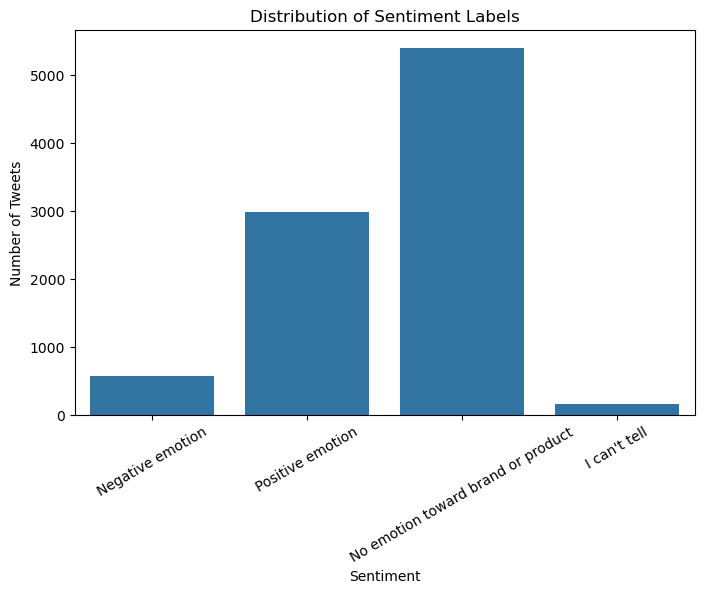

In [17]:
# Visualize sentiment label distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sentiment')
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=30)
plt.show()

### 3.7.2 Explore Product Mentions
This step examines the product column. This column shows which Apple or Google product the tweet was directed at. Exploring this column helps show which products are most represented in the dataset.

In [18]:
# Count product or brand mentions
df['product'].value_counts(dropna=False)

product
NaN                                5802
iPad                                946
Apple                               661
iPad or iPhone App                  470
Google                              430
iPhone                              297
Other Google product or service     293
Android App                          81
Android                              78
Other Apple product or service       35
Name: count, dtype: int64

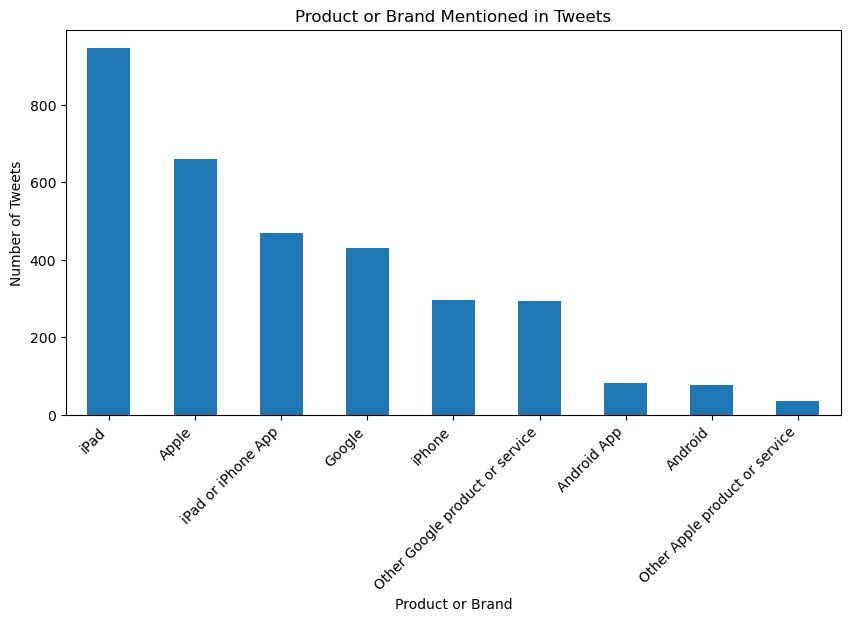

In [19]:
# Visualize product or brand mentions
plt.figure(figsize=(10, 5))
df['product'].value_counts().plot(kind='bar')
plt.title('Product or Brand Mentioned in Tweets')
plt.xlabel('Product or Brand')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45, ha='right')
plt.show()

###
## 3.9 Data Understanding Summary

The dataset has 9,093 rows and 3 columns. Each row represents a tweet about an Apple or Google product. The columns are `text`, `product`, and `sentiment`.

The `text` column has 1 missing value. Since the model will use tweet text to predict sentiment, this row will be removed during data preparation.

The `product` column has many missing values, with 5,802 missing entries. Because of this, the product column will mainly be used for exploration, not as the main modeling feature.

The `sentiment` column has no missing values. This column is the target variable for the project. The most common sentiment is `No emotion toward brand or product`, followed by `Positive emotion`. The `Negative emotion` class has fewer tweets, and `I can't tell` has the fewest tweets. This shows that the sentiment classes are imbalanced.

The dataset also has 22 duplicate rows. These will be removed during data preparation.

Overall, the dataset is useful for this NLP project because it contains tweet text and sentiment labels from Apple and Google products. The next step is to clean the data, simplify the sentiment labels, remove unclear labels, and prepare the tweet text for modeling.

# 4. Data Preparation

This section prepares the dataset for Natural Language Processing modeling. The main goal is to clean the dataset, simplify the sentiment labels, remove unclear records, and prepare tweet text so it can be converted into numerical features for machine learning.

## 4.1 Create a Working Copy of the Dataset

A copy of the dataset is created before cleaning. This keeps the original dataset unchanged and allows all preparation steps to be done on a separate DataFrame.

In [20]:
# Create a copy of the dataset for cleaning
df_clean = df.copy()

# Display the shape of the copied dataset
print("Dataset Shape:", df_clean.shape)

Dataset Shape: (9093, 3)


## 4.2 Remove Missing Tweet Text

In [21]:
# Remove rows with missing tweet text
df_clean = df_clean.dropna(subset=['text'])

In [22]:
# Check missing values again
print(df_clean.isnull().sum())

text            0
product      5801
sentiment       0
dtype: int64


In [23]:
# Check updated shape
print("Updated Dataset Shape:", df_clean.shape)

Updated Dataset Shape: (9092, 3)


### The remaining missing values are in the `product` column. These rows will not be removed because the main model will use tweet text to predict sentiment. Dropping rows with missing product values would remove a large part of the dataset. The product column will mainly be used for exploration, while the `text` column will be used as the main modeling feature.

## 4.3 Remove Duplicate Rows

In [24]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

In [25]:
# Check number of duplicate rows after removal
duplicate_count = df_clean.duplicated().sum()

In [26]:
print("Number of Duplicate Rows:", duplicate_count)
print("Updated Dataset Shape:", df_clean.shape)

Number of Duplicate Rows: 0
Updated Dataset Shape: (9070, 3)


## 4.4 Clean Sentiment Labels
The sentiment labels need to be simplified before modeling. The original labels are long, so they are changed into shorter labels that are easier to use and understand.

In [27]:
# Check current sentiment labels
df_clean['sentiment'].value_counts()

sentiment
No emotion toward brand or product    5375
Positive emotion                      2970
Negative emotion                       569
I can't tell                           156
Name: count, dtype: int64

In [28]:
# Simplify sentiment labels
df_clean['sentiment'] = df_clean['sentiment'].replace({
    'Positive emotion': 'positive',
    'Negative emotion': 'negative',
    'No emotion toward brand or product': 'neutral',
    "I can't tell": 'unclear'
})

# Check updated sentiment labels
df_clean['sentiment'].value_counts()

sentiment
neutral     5375
positive    2970
negative     569
unclear      156
Name: count, dtype: int64

## 4.5 Remove Unclear Sentiment Labels

In [29]:
# Remove unclear sentiment labels
df_clean = df_clean[df_clean['sentiment'] != 'unclear']

# Check updated sentiment counts
df_clean['sentiment'].value_counts()

sentiment
neutral     5375
positive    2970
negative     569
Name: count, dtype: int64

In [30]:
# Check updated dataset shape
print("Updated Dataset Shape:", df_clean.shape)

Updated Dataset Shape: (8914, 3)


## 4.6 Check Final Sentiment Distribution After Cleaning

In [31]:
# Check final sentiment counts
df_clean['sentiment'].value_counts()

sentiment
neutral     5375
positive    2970
negative     569
Name: count, dtype: int64

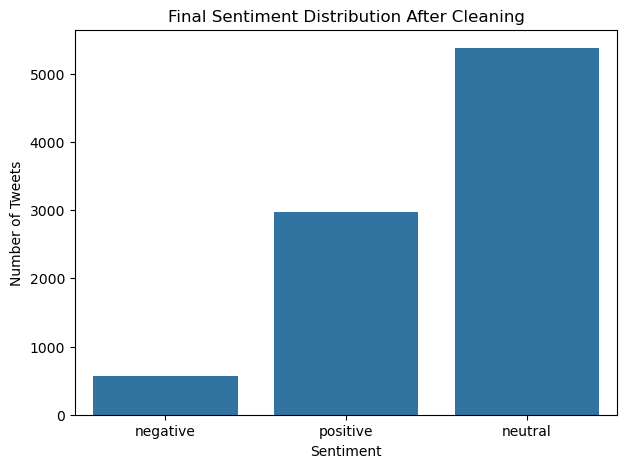

In [32]:
# Visualize final sentiment distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x='sentiment')
plt.title('Final Sentiment Distribution After Cleaning')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.show()

## 4.7 Text Preprocessing

In [33]:
# Import NLP preprocessing tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [34]:
# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sparkwave\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sparkwave\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sparkwave\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Sparkwave\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [35]:
# Create preprocessing function
def preprocess_text(text):
    # Handle missing values
    text = str(text)
    
    # Convert text to lowercase
    text = text.lower()
    
    # Remove website links
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove Twitter mentions
    text = re.sub(r'@\w+', '', text)
    
    # Remove hashtag symbol but keep the word
    text = re.sub(r'#', '', text)
    
    # Replace &amp; with "and"
    text = re.sub(r'&amp;', 'and', text)
    
    # Replace punctuation and special characters with spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # Tokenization
    tokens = nltk.word_tokenize(text)
    
    # Create stopword list
    stop_words = set(stopwords.words('english'))
    
    # Keep important negation words for sentiment analysis
    stop_words = stop_words - {'no', 'not', 'never'}
    
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # Lemmatization
    lemma = WordNetLemmatizer()
    tokens = [lemma.lemmatize(word) for word in tokens]
    
    # Join tokens back into one string
    return ' '.join(tokens)

In [36]:
# Apply preprocessing function
df_clean['clean_text'] = df_clean['text'].apply(preprocess_text)

# Display original and cleaned text
df_clean[['text', 'clean_text']].head()

,text,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,3g iphone 3 hr tweeting rise austin dead need ...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,know awesome ipad iphone app likely appreciate...
2,@swonderlin Can not wait for #iPad 2 also. The...,not wait ipad 2 also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,hope year festival crashy year iphone app sxsw
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,great stuff fri sxsw marissa mayer google tim ...


### 
## 4.9 Data Preparation Summary

The data preparation step cleaned the dataset for NLP modeling. A copy of the original dataset was created first so the original data stayed unchanged.

The row with missing tweet text was removed because tweet text is needed for sentiment prediction. Missing values in the `product` column were kept because the main model will use the `text` column, not the product column, as the main feature.

Duplicate rows were removed to prevent repeated tweets from affecting the model more than once. After removing missing tweet text and duplicates, the dataset had 9,070 rows.

The sentiment labels were simplified into shorter labels: `neutral`, `positive`, `negative`, and `unclear`. The `unclear` label was then removed because it does not provide a clear sentiment class for the model to learn. After this step, the dataset had 8,914 rows.

The final sentiment classes are imbalanced. The dataset contains 5,375 neutral tweets, 2,970 positive tweets, and 569 negative tweets. This imbalance will be considered during model evaluation.

A text preprocessing function was created to clean the tweets. The function lowercased the text, removed links and mentions, removed special characters, tokenized the text, removed common stopwords, and lemmatized words. Negation words such as `not`, `no`, and `never` were kept because they are important for sentiment analysis. Numbers were also kept because they may appear in product names or features, such as `3G` and `iPad 2`.

The dataset is now ready for modeling. The cleaned tweet text will be used as the main feature, and the sentiment label will be used as the target variable.


# 5. MODELING

## 5.1 Define Features and Target

In [37]:
# Define features and target variable
X = df_clean['clean_text']
y = df_clean['sentiment']

# Check feature and target shapes
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (8914,)
Target Shape: (8914,)


In [38]:
# Check target class distribution
y.value_counts()

sentiment
neutral     5375
positive    2970
negative     569
Name: count, dtype: int64

## 5.2 Train-Test Split

In [39]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check the shapes of the training and testing sets
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (7131,)
X_test Shape: (1783,)
y_train Shape: (7131,)
y_test Shape: (1783,)


## 5.3 TF-IDF Vectorization
TF-IDF was used to convert tweet text into numerical features that can be used by machine learning algorithms.

In [40]:
# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit vectorizer on training text and transform training text
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform testing text
X_test_tfidf = tfidf.transform(X_test)

# Check vectorized data shapes
print("X_train_tfidf Shape:", X_train_tfidf.shape)
print("X_test_tfidf Shape:", X_test_tfidf.shape)

X_train_tfidf Shape: (7131, 5000)
X_test_tfidf Shape: (1783, 5000)


## 5.4 Baseline Model: Dummy Classifier

Before training machine learning models, a baseline model was created using a Dummy Classifier. The Dummy Classifier predicts only the majority sentiment class and provides a minimum benchmark for model performance. Any machine learning model should outperform this baseline to demonstrate that it has learned meaningful patterns from the tweet text.

In [41]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create baseline model
dummy_model = DummyClassifier(strategy='most_frequent')

# Train baseline model
dummy_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_dummy = dummy_model.predict(X_test_tfidf)

# Evaluate baseline model
print("Dummy Classifier Accuracy:")
print(accuracy_score(y_test, y_pred_dummy))

print("\nDummy Classifier Classification Report:")
print(classification_report(y_test, y_pred_dummy))

Dummy Classifier Accuracy:
0.6029164329781268

Dummy Classifier Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       114
     neutral       0.60      1.00      0.75      1075
    positive       0.00      0.00      0.00       594

    accuracy                           0.60      1783
   macro avg       0.20      0.33      0.25      1783
weighted avg       0.36      0.60      0.45      1783



### Interpretation

The Dummy Classifier achieved an accuracy of 60.3%, but this result is misleading because the model predicted only the majority class (neutral) for every tweet. As a result, the model completely failed to identify both positive and negative tweets, producing a macro F1-score of approximately 0.25.

These results demonstrate why accuracy alone is not an appropriate metric for this project. Because the dataset is imbalanced, a model can achieve relatively high accuracy simply by predicting the most common class. The Dummy Classifier therefore serves as a baseline benchmark. Any machine learning model selected for deployment should substantially outperform this baseline, particularly in terms of macro F1-score and recall for the positive and negative sentiment classes.


## 5.5 Model1: Logistic Regression
Logistic Regression was selected as the first machine learning model because it is a strong baseline algorithm for text classification and performs well with TF-IDF features.

In [42]:
# Create Logistic Regression model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Train model
lr_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

# Evaluate model
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.630959057767807

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.30      0.56      0.39       114
     neutral       0.76      0.66      0.71      1075
    positive       0.56      0.59      0.57       594

    accuracy                           0.63      1783
   macro avg       0.54      0.60      0.56      1783
weighted avg       0.66      0.63      0.64      1783


Logistic Regression Confusion Matrix:
[[ 64  31  19]
 [103 713 259]
 [ 46 200 348]]


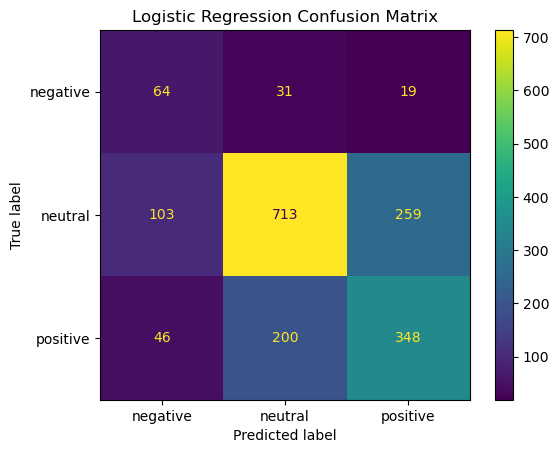

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

### Interpretation

The Logistic Regression model achieved an accuracy of 63.1% and a macro F1-score of 0.56. Unlike the Dummy Classifier, it was able to classify tweets across all three sentiment categories rather than predicting only the majority class.

The model performed best on neutral tweets (F1 = 0.71), while also showing reasonable performance for positive tweets (F1 = 0.57). It identified 56% of negative tweets, which is important because negative sentiment is the smallest class in the dataset.

The confusion matrix shows that some positive and negative tweets were still predicted as neutral. However, overall, the model demonstrated balanced performance and provides a strong benchmark for the remaining models.


## 5.6 Model Explainability

In [44]:
# Get feature names from TF-IDF
feature_names = tfidf.get_feature_names_out()

# Create DataFrame of coefficients
coef_df = pd.DataFrame(
    lr_model.coef_.T,
    index=feature_names,
    columns=lr_model.classes_
)

# Display top words for each sentiment class
for sentiment in coef_df.columns:
    
    print(f"\nTop words for '{sentiment}' sentiment:")
    
    display(
        coef_df[sentiment]
        .sort_values(ascending=False)
        .head(10)
        .to_frame(name='Coefficient')
    )


Top words for 'negative' sentiment:


,Coefficient
fail,3.555990
headache,3.115562
hate,2.933447
not,2.890517
button,2.420972
battery,2.147310
conflagration,2.098318
try,1.995266
long,1.926386
fascist,1.916878



Top words for 'neutral' sentiment:


,Coefficient
link,3.369448
sxsw,1.470134
anyone,1.330061
designing,1.258750
card,1.180205
facebook,1.151709
free,1.126079
today,1.116140
plenty,1.112248
congress,1.086445



Top words for 'positive' sentiment:


,Coefficient
cool,2.914230
great,2.511134
smart,2.329796
awesome,2.246966
fun,2.200391
love,2.119407
wow,1.947627
must,1.767339
ipad,1.722783
win,1.689737


### Interpretation

The Logistic Regression coefficients provide insight into the words that influenced sentiment predictions. For the negative class, words such as *fail*, *headache*, *hate*, *battery*, and *not* were strongly associated with negative sentiment, suggesting that the model learned to identify language related to problems, dissatisfaction, and product issues.

For the positive class, words such as *cool*, *great*, *awesome*, *fun*, and *love* were among the strongest predictors. These words reflect favorable opinions and positive user experiences.

The neutral class was associated with more informational or event-related terms such as *link*, *sxsw*, *facebook*, and *today*. This suggests that the model learned to distinguish opinionated language from tweets that primarily share information or discuss events without expressing strong sentiment.

Overall, the influential words align with expectations, providing confidence that the model is learning meaningful sentiment patterns from the tweet text.


## 5.7 Model 2: Decision Tree
A Decision Tree classifier was selected as the first tree-based model for comparison. Unlike Logistic Regression, which learns linear relationships between features and sentiment classes, Decision Trees can capture more complex patterns by repeatedly splitting the data based on feature values.

In [46]:
# Import Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test_tfidf)

In [47]:
# Evaluate Decision Tree model
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy:
0.6001121704991588

Decision Tree Classification Report:
              precision    recall  f1-score   support

    negative       0.33      0.22      0.26       114
     neutral       0.68      0.71      0.70      1075
    positive       0.48      0.47      0.47       594

    accuracy                           0.60      1783
   macro avg       0.50      0.47      0.48      1783
weighted avg       0.59      0.60      0.59      1783


Decision Tree Confusion Matrix:
[[ 25  58  31]
 [ 32 768 275]
 [ 18 299 277]]


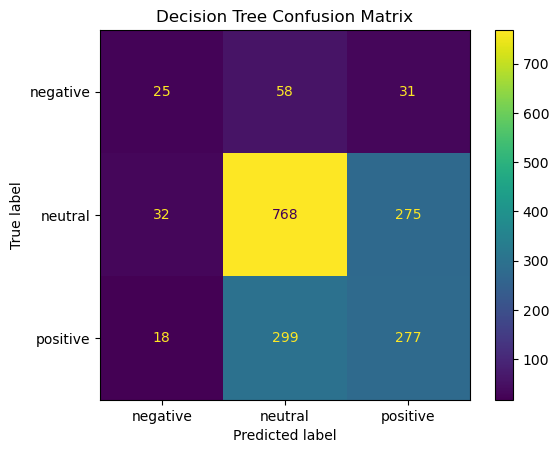

In [48]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Decision Tree Confusion Matrix")
plt.show()

### Interpretation

The Decision Tree model achieved an accuracy of 60.0% and a macro F1-score of 0.48. The model was able to classify tweets across all three sentiment categories, although performance varied between classes.

The model performed best on neutral tweets, while negative tweets remained the most difficult class to identify. The relatively low recall for the negative class suggests that many negative tweets were incorrectly classified as either neutral or positive.

## 5.8 Model 3: Tuned Decision Tree
Decision Trees can easily overfit training data, especially when working with thousands of text features. To improve generalization, a tuned Decision Tree model was created by restricting tree growth through hyperparameter adjustments.
The parameters were selected to reduce model complexity while maintaining predictive performance. The goal was to determine whether a more controlled tree structure could improve results on unseen data.


In [49]:
# Create tuned Decision Tree model
dt_tuned = DecisionTreeClassifier(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train the tuned Decision Tree model
dt_tuned.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_dt_tuned = dt_tuned.predict(X_test_tfidf)

In [50]:
# Evaluate tuned Decision Tree model
print("Tuned Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt_tuned))

print("\nTuned Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt_tuned))

print("\nTuned Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_tuned))

Tuned Decision Tree Accuracy:
0.6180594503645541

Tuned Decision Tree Classification Report:
              precision    recall  f1-score   support

    negative       0.34      0.09      0.14       114
     neutral       0.65      0.83      0.73      1075
    positive       0.51      0.34      0.41       594

    accuracy                           0.62      1783
   macro avg       0.50      0.42      0.43      1783
weighted avg       0.59      0.62      0.59      1783


Tuned Decision Tree Confusion Matrix:
[[ 10  83  21]
 [ 13 892 170]
 [  6 388 200]]


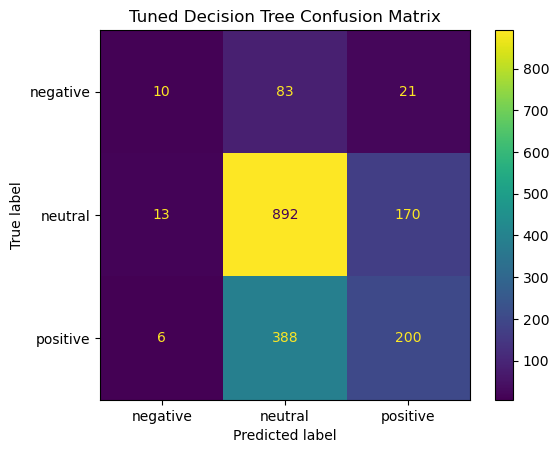

In [51]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt_tuned)
plt.title("Tuned Decision Tree Confusion Matrix")
plt.show()

### Interpretation
The Tuned Decision Tree achieved an accuracy of 61.8%. The tuning process slightly improved overall accuracy compared to the original Decision Tree, indicating that reducing model complexity helped the model generalize better to unseen data.
Despite this improvement, the model continued to struggle with the minority negative class. Many negative tweets were still misclassified, suggesting that additional modeling approaches may be needed to better capture sentiment patterns within the dataset.

## 5.9 Model 4: Random Forest
Random Forest was selected as an ensemble model for comparison because it extends the Decision Tree approach by combining predictions from multiple trees rather than relying on a single tree. This ensemble approach helps reduce overfitting and often improves predictive performance.

In [53]:
# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the Random Forest model
rf_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_tfidf)

In [54]:
# Evaluate Random Forest model
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy:
0.6724621424565339

Random Forest Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.18      0.28       114
     neutral       0.68      0.87      0.77      1075
    positive       0.63      0.41      0.50       594

    accuracy                           0.67      1783
   macro avg       0.67      0.49      0.51      1783
weighted avg       0.67      0.67      0.65      1783


Random Forest Confusion Matrix:
[[ 20  82  12]
 [  8 934 133]
 [  1 348 245]]


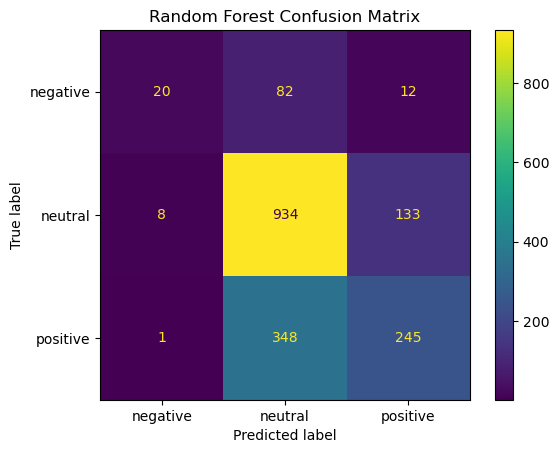

In [56]:
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

### Interpretation

The Random Forest model achieved an accuracy of 67.2% and a macro F1-score of 0.52. The model performed best on neutral tweets, correctly identifying most observations in the largest class.

Performance for positive tweets improved compared to the Decision Tree models, while negative sentiment remained the most difficult class to classify. Although the model correctly identified some negative tweets, many were still predicted as neutral.

Overall, the Random Forest model demonstrated stronger and more consistent performance than the individual Decision Tree models, suggesting that the ensemble approach was more effective at capturing sentiment patterns within the tweet data.

## 5.10 Model Comparison

In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_results = pd.DataFrame({

    'Model': [
        'Dummy Classifier',
        'Logistic Regression',
        'Decision Tree',
        'Tuned Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_dt_tuned),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Macro Precision': [
        precision_score(y_test, y_pred_dummy, average='macro', zero_division=0),
        precision_score(y_test, y_pred_lr, average='macro'),
        precision_score(y_test, y_pred_dt, average='macro'),
        precision_score(y_test, y_pred_dt_tuned, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro')
    ],

    'Macro Recall': [
        recall_score(y_test, y_pred_dummy, average='macro'),
        recall_score(y_test, y_pred_lr, average='macro'),
        recall_score(y_test, y_pred_dt, average='macro'),
        recall_score(y_test, y_pred_dt_tuned, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro')
    ],

    'Macro F1-Score': [
        f1_score(y_test, y_pred_dummy, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_dt_tuned, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],

    'Negative Recall': [
        recall_score(y_test, y_pred_dummy,
                     labels=['negative'],
                     average=None)[0],

        recall_score(y_test, y_pred_lr,
                     labels=['negative'],
                     average=None)[0],

        recall_score(y_test, y_pred_dt,
                     labels=['negative'],
                     average=None)[0],

        recall_score(y_test, y_pred_dt_tuned,
                     labels=['negative'],
                     average=None)[0],

        recall_score(y_test, y_pred_rf,
                     labels=['negative'],
                     average=None)[0]
    ]
})

model_results.round(3)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Negative Recall
0,Dummy Classifier,0.603,0.201,0.333,0.251,0.000
1,Logistic Regression,0.631,0.537,0.604,0.556,0.561
2,Decision Tree,0.600,0.497,0.467,0.478,0.219
3,Tuned Decision Tree,0.618,0.504,0.418,0.426,0.088
4,Random Forest,0.672,0.668,0.486,0.515,0.175


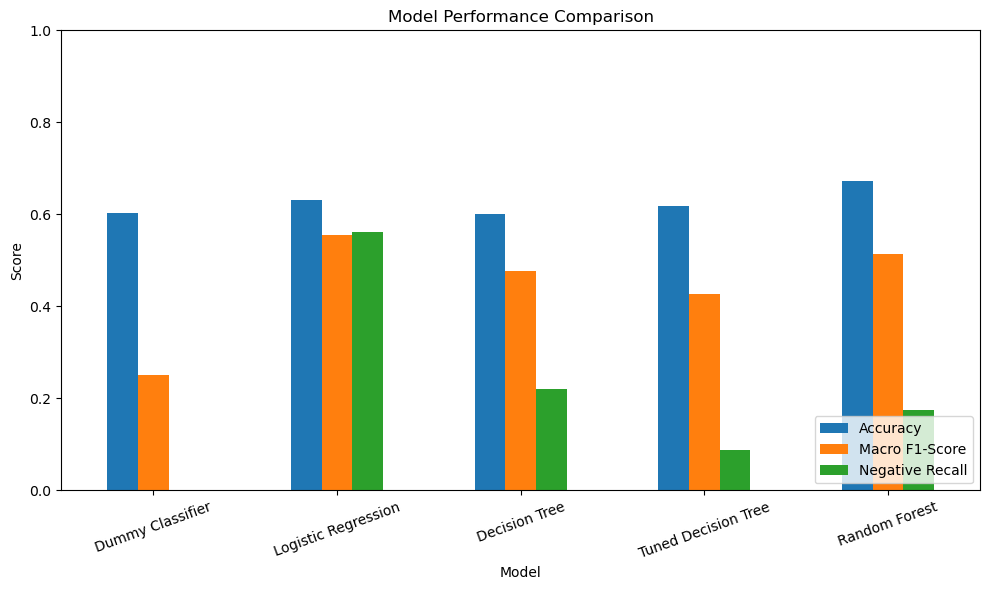

In [58]:
# Plot model comparison

comparison_metrics = model_results[
    ['Model', 'Accuracy', 'Macro F1-Score', 'Negative Recall']
]

comparison_metrics = comparison_metrics.set_index('Model')

comparison_metrics.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### Interpretation
The results show a clear improvement from the baseline Dummy Classifier to the machine learning models. While the Dummy Classifier achieved over 60% accuracy, it failed to identify any positive or negative tweets because it predicted only the majority class.

Among the machine learning models, Logistic Regression achieved the highest macro F1-score (0.556) and the highest negative recall (0.561). This indicates that it provided the most balanced performance across the three sentiment classes while also being the most effective at identifying negative tweets.

The Random Forest model achieved the highest overall accuracy (0.672). However, its macro F1-score and negative recall were lower than those of Logistic Regression. Since this project prioritizes balanced classification performance and the detection of negative sentiment, Logistic Regression demonstrated the strongest overall performance.

## 5.11 Final Model Selection

Based on the model comparison results, Logistic Regression was selected as the final model for this project. Although Random Forest achieved the highest overall accuracy, Logistic Regression produced the highest macro F1-score and the highest recall for negative tweets.

Because the dataset is imbalanced, macro F1-score was considered the most appropriate metric for evaluating overall model performance. In addition, accurately identifying negative sentiment is important from a business perspective because negative tweets may indicate customer dissatisfaction, product issues, or areas requiring attention.

The Logistic Regression model demonstrated the best balance across all three sentiment classes while maintaining strong performance on the minority negative class. Therefore, it was selected as the final model for the sentiment classification task.

# 6. Evaluation

### 6.1 Final Model Evaluation

Logistic Regression was selected as the final model because it achieved the highest macro F1-score and the highest recall for negative tweets among the models tested. While Random Forest produced slightly higher accuracy, Logistic Regression provided more balanced performance across all sentiment classes.
The final model achieved an accuracy of 63.1% and a macro F1-score of 0.56. It correctly identified 56% of negative tweets, which is important because negative sentiment represents the smallest class in the dataset and is often the most actionable from a business perspective.

In [59]:
# Final model predictions
final_predictions = y_pred_lr

print("Final Model: Logistic Regression")

print("\nAccuracy:")
print(accuracy_score(y_test, final_predictions))

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_predictions))

Final Model: Logistic Regression

Accuracy:
0.630959057767807

Classification Report:
              precision    recall  f1-score   support

    negative       0.30      0.56      0.39       114
     neutral       0.76      0.66      0.71      1075
    positive       0.56      0.59      0.57       594

    accuracy                           0.63      1783
   macro avg       0.54      0.60      0.56      1783
weighted avg       0.66      0.63      0.64      1783


Confusion Matrix:
[[ 64  31  19]
 [103 713 259]
 [ 46 200 348]]


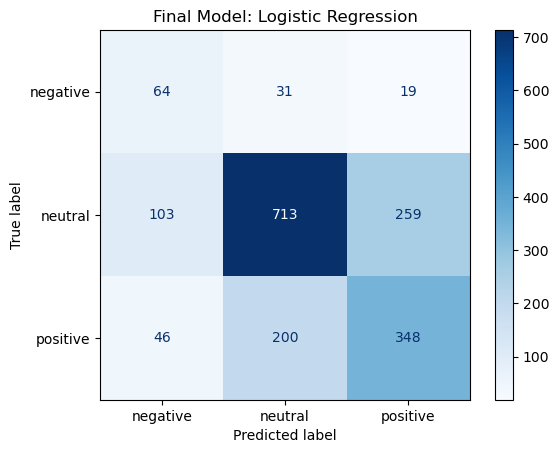

In [60]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    cmap='Blues'
)

plt.title("Final Model: Logistic Regression")
plt.show()

The final Logistic Regression model achieved an accuracy of 63.1% and a macro F1-score of 0.56. The model successfully classified tweets across all three sentiment categories and demonstrated balanced performance despite the class imbalance present in the dataset.
The model performed best on neutral tweets while also maintaining reasonable performance on positive tweets. It identified more than half of all negative tweets, which is particularly valuable because negative sentiment is the least represented class in the dataset. Overall, the results indicate that the model learned meaningful sentiment patterns from tweet text and can be used to support automated sentiment analysis.

## 6.2 Business Evaluation
The objective of this project was to develop a model capable of automatically classifying tweets about Apple and Google products as positive, neutral, or negative. The results indicate that the model is able to distinguish between sentiment categories and identify meaningful patterns within tweet text.
The model was particularly effective at identifying negative tweets compared to the other models evaluated. This is valuable because negative sentiment may signal customer dissatisfaction, product issues, or areas where companies may need to respond. Although the model is not perfect and some tweets are still misclassified, it demonstrates that sentiment analysis can provide useful insights into customer opinions at scale.
Overall, the model provides a practical proof of concept that could help organizations monitor public sentiment and identify trends in customer feedback more efficiently than manual review alone.

## 6.3 Limitations and Future Work

The primary limitation of this project is class imbalance, as neutral tweets greatly outnumber negative tweets. In addition, tweets often contain abbreviations, slang, and sarcasm that can be difficult for traditional machine learning models to interpret correctly.
Future work could explore more advanced natural language processing techniques, including transformer-based models such as BERT. Additional improvements may also be achieved through larger datasets, improved text preprocessing, and techniques designed to address class imbalance.